In [1]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def detect_red_point(frame):
    """
    Detect the largest red blob in the frame and return its centroid (x, y).
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no red object is detected.
    """
    annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Red wraps around in HSV, so use two ranges
    lower_red1 = np.array([0, 100, 50])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 100, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.bitwise_or(mask1, mask2)

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:
        return None, None, mask, annotated

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)
    cv2.drawContours(annotated, [largest], -1, (255, 0, 0), 2)
    cv2.putText(
        annotated,
        f"({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [3]:
def detect_green_point(frame):
    """
    Detect the largest green blob in the frame and return its centroid (x, y).
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no green object is detected.
    """
    annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Red wraps around in HSV, so use two ranges
    lower_green = np.array([40, 80, 50])
    upper_green = np.array([85, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:
        return None, None, mask, annotated

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)
    cv2.drawContours(annotated, [largest], -1, (255, 0, 0), 2)
    cv2.putText(
        annotated,
        f"({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [4]:
def process_video(video_path, output_csv, preview=True, save_annotated=False):
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if save_annotated:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        annotated_path = video_path.with_name(video_path.stem + "_tracked.mp4")
        writer = cv2.VideoWriter(str(annotated_path), fourcc, fps, (width, height))

    results = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        xR, yR, maskR, annR = detect_red_point(frame)
        xG, yG, maskG, annG = detect_green_point(frame)

        time_s = frame_idx / fps if fps > 0 else np.nan
        annotated = frame.copy()
        if xR is not None:
            cv2.circle(annotated, (xR, yR), 6, (0, 0, 255), -1)

        if xG is not None:
            cv2.circle(annotated, (xG, yG), 6, (0, 255, 0), -1)
        results.append({
            "frame": frame_idx,
            "time_s": time_s,
            "x_red": xR,
            "y_red": yR,
            "x_green": xG,
            "y_green": yG
        })

        if writer is not None:
            writer.write(annotated)

        if preview:
            combined_mask = cv2.cvtColor(maskR|maskG, cv2.COLOR_GRAY2BGR)
            top = np.hstack((frame, annotated))
            bottom = np.hstack((combined_mask, np.zeros_like(combined_mask)))
            display = np.vstack((top, bottom))

            scale = 0.7
            display = cv2.resize(display, None, fx=scale, fy=scale)

            cv2.imshow("Original | Annotated / Mask", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                break

        frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"Done. Saved coordinates to: {output_csv}")
    if save_annotated:
        print(f"Saved annotated video to: {annotated_path}")

    missing_total = (
    df["x_red"].isna().sum() +
    df["x_green"].isna().sum()
    )
    print(f"Frames with missing detection (red + green): {missing_total}")


In [11]:

video = "IMG_9456.MOV"
output = "20260710_141408.csv"

process_video(
        video_path=video,
        output_csv=output,
        preview=True,
        save_annotated=True
    )



Done. Saved coordinates to: 20260710_141408.csv
Saved annotated video to: IMG_9456_tracked.mp4
Frames with missing detection (red + green): 51


In [6]:
def export_first_frame(
    video_path,
    output_png=None,
    dpi=300
):
    """
    Export the first frame of a video as a PNG.

    The exported image keeps exactly the same pixel width and height
    as the original video frame.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video.

    output_png : str or Path, optional
        Output PNG path. If None, the output name will be:
        <video_name>_first_frame.png

    dpi : float
        DPI metadata written to the PNG.
        DPI does not change the number of pixels or image quality.
    """

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}"
        )

    if output_png is None:
        output_png = video_path.with_name(
            video_path.stem + "_first_frame.png"
        )
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    success, frame = cap.read()
    cap.release()

    if not success or frame is None:
        raise RuntimeError(
            "Could not read the first frame from the video."
        )

    height, width = frame.shape[:2]

    # OpenCV writes the original pixel data without resizing.
    success = cv2.imwrite(
        str(output_png),
        frame,
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )

    if not success:
        raise RuntimeError(
            f"Could not save PNG: {output_png}"
        )

    # OpenCV does not reliably write DPI metadata, so add it using Pillow.
    try:
        from PIL import Image

        with Image.open(output_png) as image:
            image.save(
                output_png,
                dpi=(dpi, dpi)
            )

    except ImportError:
        print(
            "Pillow is not installed, so DPI metadata was not added."
        )
        print(
            "Install it with: pip install pillow"
        )

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels")
    print(f"DPI metadata: {dpi} DPI")

    return output_png

In [7]:
export_first_frame(
    video_path=video,
    output_png="20260710_141408_first_frame.png",
    dpi=300
)

Saved first frame to: 20260710_141408_first_frame.png
Resolution: 2160 x 3840 pixels
DPI metadata: 300 DPI


WindowsPath('20260710_141408_first_frame.png')

x_red: (676,)
y_red: (676,)
x_green: (676,)
y_green: (676,)


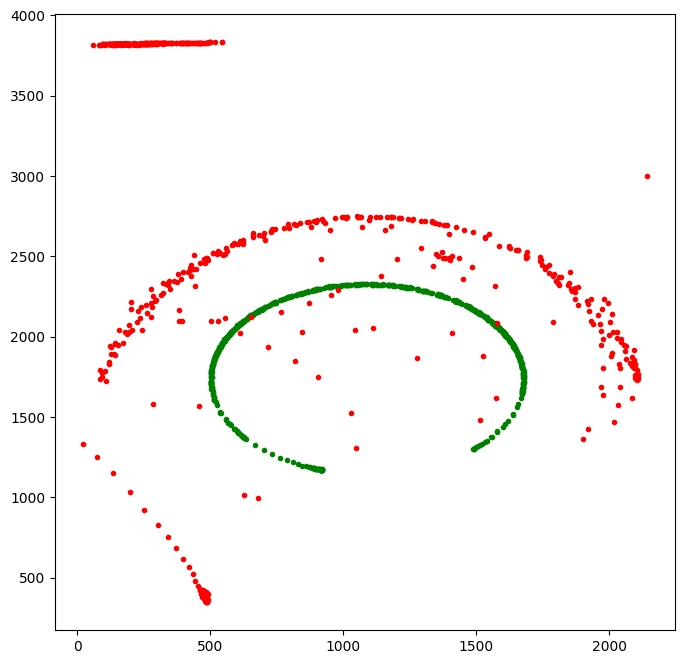

In [12]:
df = pd.read_csv("20260710_141408.csv")

# Rode marker
x_red = df["x_red"].to_numpy()
y_red = df["y_red"].to_numpy()
x_green = df["x_green"].to_numpy()
y_green = df["y_green"].to_numpy()

print("x_red:", x_red.shape)
print("y_red:", y_red.shape)
print("x_green:", x_green.shape)
print("y_green:", y_green.shape)

plt.figure(figsize=(8,8))
plt.plot(x_green,y_green,'g.')
plt.plot(x_red,y_red,'r.')
plt.show()